#### Imports and Setups


In [1]:
import os
import yaml
import operator
from pathlib import Path
from typing import TypedDict
from dotenv import load_dotenv
from rich.markdown import Markdown
from typing import Annotated
from langgraph_utils import console
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

True

In [2]:
params_configs = yaml.safe_load(Path("configs/params.yaml").read_text())
prompts_configs = yaml.safe_load(Path("configs/prompts.yaml").read_text())

#### Output Schema


In [3]:
class LlmSchema(BaseModel):
    score: float = Field(
        description=params_configs["LlmSchema"]["score_description"],
        ge=params_configs["LlmSchema"]["score_ge"],
        le=params_configs["LlmSchema"]["score_le"],
    )

    feedback: str = Field(
        description=params_configs["LlmSchema"]["feedback_description"]
    )

#### Model


In [4]:
model = ChatGoogleGenerativeAI(**params_configs["llm"])
structured_model = model.with_structured_output(LlmSchema)

#### State


In [5]:
class BlogState(TypedDict):
    blog_content: str

    content_quality_score: float
    content_quality_feedback: str

    cta_score: float
    cta_feedback: str

    seo_score: float
    seo_feedback: str

    scores: Annotated[list[float], operator.add]
    average_score: float

#### Node Functions

In [6]:
def evaluate_content_quality(state: BlogState):
    prompt = ChatPromptTemplate(
        [
            ("system", prompts_configs["evaluate_content_quality"]["system_prompt"]),
            ("user", prompts_configs["evaluate_content_quality"]["user_prompt"]),
        ]
    )

    chain = prompt | structured_model
    res = chain.invoke({"blog_content": state["blog_content"]})

    return {
        "content_quality_score": res.score,
        "content_quality_feedback": res.feedback,
        "scores": [res.score],
    }

In [7]:
def evaluate_cta(state: BlogState):

    prompt = ChatPromptTemplate(
        [
            ("system", prompts_configs["evaluate_cta"]["system_prompt"]),
            ("user", prompts_configs["evaluate_cta"]["user_prompt"]),
        ]
    )

    chain = prompt | structured_model
    res = chain.invoke({"blog_content": state["blog_content"]})

    return {
        "cta_score": res.score,
        "cta_feedback": res.feedback,
        "scores": [res.score],
    }

In [8]:
def evaluate_seo(state: BlogState):
    prompt = ChatPromptTemplate(
        [
            ("system", prompts_configs["evaluate_seo"]["system_prompt"]),
            ("user", prompts_configs["evaluate_seo"]["user_prompt"]),
        ]
    )

    chain = prompt | structured_model
    res = chain.invoke({"blog_content": state["blog_content"]})

    return {
        "seo_score": res.score,
        "seo_feedback": res.feedback,
        "scores": [res.score],
    }

In [9]:
def calculate_average_score(state: BlogState):
    return {
        "average_score": round(
            sum(state["scores"]) / len(state["scores"]),
            2,
        )
        if state["scores"]
        else 0.0
    }

#### Init Graph


In [10]:
graph = StateGraph(BlogState)

#### Add Nodes


In [11]:
graph.add_node("evaluate_content_quality", evaluate_content_quality)
graph.add_node("evaluate_cta", evaluate_cta)
graph.add_node("evaluate_seo", evaluate_seo)
graph.add_node("calculate_average_score", calculate_average_score)

#### Add Edges


In [12]:
graph.add_edge(START, "evaluate_content_quality")
graph.add_edge(START, "evaluate_cta")
graph.add_edge(START, "evaluate_seo")

graph.add_edge("evaluate_content_quality", "calculate_average_score")
graph.add_edge("evaluate_cta", "calculate_average_score")
graph.add_edge("evaluate_seo", "calculate_average_score")

graph.add_edge("calculate_average_score", END)

#### Compilation


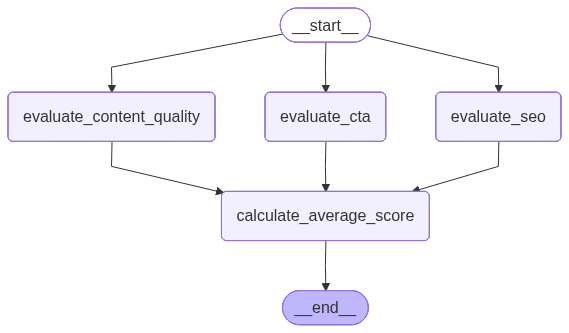

In [13]:
workflow = graph.compile()
workflow

#### Ingest Data

In [14]:
with open(params_configs["filenames"]["blog_filepath"], "r") as f:
    blog_content = f.read()

console.print(Markdown(blog_content))

                            Unveiling Distant Skies: A Deep Dive into Exoplanet Atmospheres                             

1. Introduction: Whispers from Alien Worlds                                                                             

1.1. The Allure of Distant Planets                                                                                      

For millennia, humanity has gazed at the stars, wondering if other worlds exist beyond our solar system. That ancient   
curiosity has evolved into a vibrant scientific quest, with over 5,500 exoplanets (planets orbiting stars other than our
Sun) now confirmed. Each discovery deepens our understanding of planetary diversity, but to truly grasp what these      
distant worlds are like, we must look beyond their size and orbit and peer into their most defining feature: their      
atmospheres.                                                                                                            

1.2. What Are Exoplanet Atmo

#### Execution


In [15]:
final_state = workflow.invoke({"blog_content": blog_content, "scores": []})

In [16]:
console.print_json(
    data={
        k: v
        for k, v in final_state.items()
        if k in ["content_quality_score", "cta_score", "seo_score", "average_score"]
    }
)

{
  "content_quality_score": 7.5,
  "cta_score": 5.5,
  "seo_score": 9.5,
  "average_score": 7.5
}


In [17]:
console.print(Markdown(final_state["content_quality_feedback"]))


  1 Paragraph Density Many paragraphs, particularly in sections 1.3, 2.1.2, and 2.2.3, are quite long and packed with   
    information. Breaking these into shorter, more focused paragraphs would significantly enhance skimmability for      
    digital readers.                                                                                                    
  2 Bullet Point Utilization While used in some lists, bullet points could be more consistently applied to break down   
    complex explanations, such as in "Key Observables" or "Insights Gained" sections. This would improve visual         
    hierarchy and make information easier to digest.                                                                    
  3 Sentence Complexity Several sentences are lengthy and contain multiple clauses, which can challenge reader          
    comprehension. Simplifying these sentences or splitting them into two would improve clarity and flow, especially    
    given the technical nature 

In [18]:
console.print(Markdown(final_state["cta_feedback"]))


 1 Engaging Introduction The hook effectively captures attention by connecting to ancient human curiosity and clearly   
   states the value proposition by outlining the "why" and "what" of exoplanet atmospheres.                             
 2 Comprehensive Value Delivery The core body paragraphs deliver exceptional value, thoroughly answering reader intent  
   with detailed explanations of atmospheric fundamentals, detection techniques, diverse discoveries, and future        
   challenges.                                                                                                          
 3 Structured Content Flow The use of clear headings, subheadings, and bullet points significantly enhances readability 
   and allows for easy digestion of complex scientific information, making the deep dive accessible.                    
 4 Rich Terminology Use The post effectively introduces and explains scientific terms (e.g., biosignatures, transit     
   spectroscopy, hydrodynamic e

In [19]:
console.print(Markdown(final_state["seo_feedback"]))


 1 Keyword Integration The primary keyword "Exoplanet Atmospheres" is expertly woven throughout the title, introduction,
   and subsequent headings, ensuring strong topical relevance. The natural density and use of related long-tail keywords
   like "biosignatures" and "transit spectroscopy" enhance search visibility without feeling forced.                    
 2 Heading Structure The hierarchical use of H1, H2, H3, and H4 tags is exemplary, providing a clear, logical flow and  
   exceptional scannability for complex scientific information. This structure significantly improves user experience   
   and helps search engines understand the content's organization.                                                      
 3 Meta Description Readiness The introductory sections, particularly "1.1. The Allure of Distant Planets" and "1.4.    
   Blog Post Overview," offer rich, concise summaries perfect for crafting an engaging and keyword-rich meta            
   description. This will entic

In [20]:
files_dirname = params_configs["filenames"]["dirname"]
os.makedirs(files_dirname, exist_ok=True)

content_quality_feedback_filepath = os.path.join(
    files_dirname, params_configs["filenames"]["content_quality_feedback"]
)
cta_feedback_filepath = os.path.join(
    files_dirname, params_configs["filenames"]["cta_feedback"]
)
seo_feedback_filepath = os.path.join(
    files_dirname, params_configs["filenames"]["seo_feedback"]
)

with open(content_quality_feedback_filepath, "w") as f:
    f.write(f"Content Quality Score : {final_state['content_quality_score']}\n")
    f.write(final_state["content_quality_feedback"])

with open(cta_feedback_filepath, "w") as f:
    f.write(f"CTA Score : {final_state['cta_score']}\n")
    f.write(final_state["cta_feedback"])

with open(seo_feedback_filepath, "w") as f:
    f.write(f"SEO Score : {final_state['seo_score']}\n")
    f.write(final_state["seo_feedback"])